# Train ANC Notebook Script
Final single-control training recipe:
- x_p = [gcc_phat, psd_features]
- x_s = processed/path_features -> train-split standardization -> PCA(32)
- y_raw = processed/w_targets -> train-split standardization -> PCA(32)
- model predicts y latent, but optimization and checkpoint selection use reconstructed raw W MSE



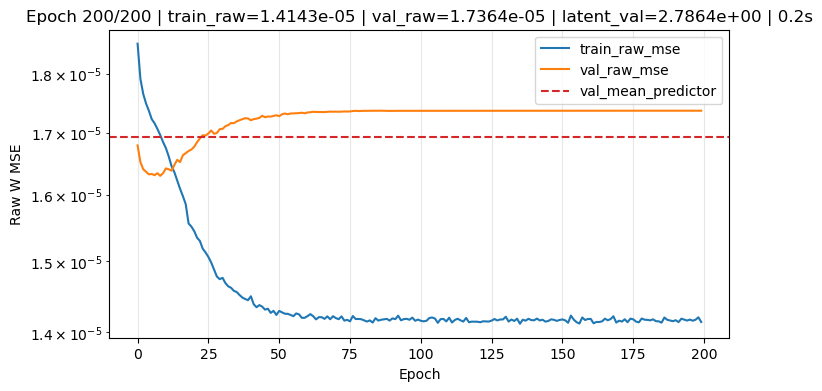

Epoch 200 | train_raw=1.414325e-05 | val_raw=1.736395e-05 | train_latent=3.349113e+00 | val_latent=2.786408e+00 | lr=1.221e-08
Best checkpoint: best_mimo_anc_net_single_control.pth
Final checkpoint: final_mimo_anc_net_single_control.pth
Best val_raw_mse: 1.6299566013913135e-05


In [1]:
from pathlib import Path
import json
import os
import random
import sys
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import clear_output
from torch.utils.data import DataLoader, TensorDataset


def _find_repo_root() -> Path:
    cwd = Path.cwd()
    for parent in [cwd] + list(cwd.parents):
        if (parent / "python_impl").exists() and (parent / "README.md").exists():
            return parent
    raise FileNotFoundError("Could not locate repository root from current working directory.")


ROOT = _find_repo_root()
os.chdir(ROOT)
if str(ROOT / "python_impl") not in sys.path:
    sys.path.insert(0, str(ROOT / "python_impl"))
print("Working directory:", ROOT)

from python_scripts.single_control_anc_common import (
    PCAProjector,
    SingleControlANCNet,
    stats_from_train,
    standardize_array,
)


def _resolve_h5_path(explicit_path: str | None = None) -> Path:
    candidates: list[Path] = []
    if explicit_path:
        candidates.append(Path(explicit_path))
    env_path = os.environ.get("ANC_H5_PATH")
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend(
        [
            Path("python_impl") / "python_scripts" / "cfxlms_qc_dataset_single_control.h5",
            Path("python_impl") / "python_scripts" / "cfxlms_qc_dataset_single_control_500_seeded.h5",
        ]
    )
    checked: list[str] = []
    for candidate in candidates:
        resolved = candidate if candidate.is_absolute() else (ROOT / candidate).resolve()
        checked.append(str(resolved))
        if resolved.exists():
            return resolved
    raise FileNotFoundError(
        "Single-control dataset HDF5 was not found. "
        "Generate python_impl/python_scripts/cfxlms_qc_dataset_single_control.h5 "
        f"or set ANC_H5_PATH. Checked: {checked}"
    )


def _cpu_state_dict(module):
    return {k: v.detach().cpu() for k, v in module.state_dict().items()}


def _normalize_columns(x_arr: np.ndarray) -> np.ndarray:
    denom = np.max(np.abs(x_arr), axis=0, keepdims=True)
    denom = np.where(denom < np.finfo(float).eps, 1.0, denom)
    return x_arr / denom


def _raw_mean_predictor_mse(y_raw: np.ndarray, train_idx: np.ndarray, val_idx: np.ndarray) -> float:
    y_mean = np.asarray(y_raw[train_idx], dtype=np.float32).mean(axis=0, dtype=np.float64).astype(np.float32)
    return float(np.mean((np.asarray(y_raw[val_idx], dtype=np.float32) - y_mean[None, :]) ** 2))


SEED = 20260331
VAL_FRAC = 0.20
BATCH_SIZE = 64
EPOCHS = 200
LR = 8.0e-4
WEIGHT_DECAY = 1.0e-4
DROPOUT = 0.15
XS_PCA_DIM = 32
Y_PCA_DIM = 32
LATENT_LOSS_WEIGHT = 0.0
RAW_LOSS_WEIGHT = 1.0


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

H5_PATH = _resolve_h5_path()
print("HDF5 dataset:", H5_PATH)
CHECKPOINT_PATH = Path("best_mimo_anc_net_single_control.pth")
FINAL_CHECKPOINT_PATH = Path("final_mimo_anc_net_single_control.pth")

with h5py.File(str(H5_PATH), "r") as h5:
    gcc = np.asarray(h5["processed/gcc_phat"], dtype=np.float32)
    psd = np.asarray(h5["processed/psd_features"], dtype=np.float32)
    x_p = np.concatenate([gcc, psd[:, None, :]], axis=1).astype(np.float32)
    x_s_raw = np.asarray(h5["processed/path_features"], dtype=np.float32)
    y_raw = np.asarray(h5["processed/w_targets"], dtype=np.float32)
    DATASET_PROCESSED_META = {
        "path_feature_dim": int(h5["processed"].attrs["path_feature_dim"]),
        "w_target_dim": int(h5["processed"].attrs["w_target_dim"]),
        "s_keep_len": int(h5["processed"].attrs["s_keep_len"]),
        "e2r_keep_len": int(h5["processed"].attrs["e2r_keep_len"]),
        "s2r_keep_len": int(h5["processed"].attrs["s2r_keep_len"]),
        "w_keep_len": int(h5["processed"].attrs["w_keep_len"]),
        "path_feature_slices_json": str(h5["processed"].attrs["path_feature_slices_json"]),
        "w_target_slices_json": str(h5["processed"].attrs["w_target_slices_json"]),
    }
    DATASET_CONFIG_JSON = str(h5.attrs["config_json"])

n = int(x_p.shape[0])
indices = np.arange(n, dtype=np.int64)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)
split = int(n * (1.0 - VAL_FRAC))
train_idx = np.sort(indices[:split])
val_idx = np.sort(indices[split:])

x_p_stats = stats_from_train(x_p, train_idx)
x_s_stats = stats_from_train(x_s_raw, train_idx)
y_stats = stats_from_train(y_raw, train_idx)

x_p_z = standardize_array(x_p, x_p_stats["mean"], x_p_stats["std"])
x_s_z = standardize_array(x_s_raw, x_s_stats["mean"], x_s_stats["std"])
y_z = standardize_array(y_raw, y_stats["mean"], y_stats["std"])

x_s_projector = PCAProjector.fit(x_s_z[train_idx], XS_PCA_DIM)
y_projector = PCAProjector.fit(y_z[train_idx], Y_PCA_DIM)

x_s_input = x_s_projector.transform(x_s_z)
y_latent = y_projector.transform(y_z)

baseline_raw_mse = _raw_mean_predictor_mse(y_raw, train_idx, val_idx)
print("x_p shape:", x_p.shape, "x_s_raw shape:", x_s_raw.shape, "y_raw shape:", y_raw.shape)
print("x_s PCA dim:", x_s_projector.output_dim, "y latent dim:", y_projector.output_dim)
print("Val raw mean-predictor baseline MSE:", baseline_raw_mse)

train_ds = TensorDataset(
    torch.from_numpy(x_p_z[train_idx]),
    torch.from_numpy(x_s_input[train_idx]),
    torch.from_numpy(y_latent[train_idx]),
    torch.from_numpy(y_raw[train_idx]),
)
val_ds = TensorDataset(
    torch.from_numpy(x_p_z[val_idx]),
    torch.from_numpy(x_s_input[val_idx]),
    torch.from_numpy(y_latent[val_idx]),
    torch.from_numpy(y_raw[val_idx]),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type == "cuda"), generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"))

model = SingleControlANCNet(x_s_dim=x_s_projector.output_dim, latent_dim=y_projector.output_dim, dropout=DROPOUT).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=8, factor=0.5)
y_stats_mean_t = torch.as_tensor(y_stats["mean"], dtype=torch.float32, device=device)
y_stats_std_t = torch.as_tensor(y_stats["std"], dtype=torch.float32, device=device)

train_raw_hist = []
val_raw_hist = []
train_latent_hist = []
val_latent_hist = []
best_val_raw = float("inf")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_raw_sum = 0.0
    train_latent_sum = 0.0
    train_count = 0
    for x_p_b, x_s_b, y_latent_b, y_raw_b in train_loader:
        x_p_b = x_p_b.to(device=device, dtype=torch.float32, non_blocking=True)
        x_s_b = x_s_b.to(device=device, dtype=torch.float32, non_blocking=True)
        y_latent_b = y_latent_b.to(device=device, dtype=torch.float32, non_blocking=True)
        y_raw_b = y_raw_b.to(device=device, dtype=torch.float32, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred_latent = model(x_p_b, x_s_b)
        pred_yz = y_projector.inverse_torch(pred_latent)
        pred_raw = pred_yz * y_stats_std_t + y_stats_mean_t
        loss_latent = F.mse_loss(pred_latent, y_latent_b)
        loss_raw = F.mse_loss(pred_raw, y_raw_b)
        loss = LATENT_LOSS_WEIGHT * loss_latent + RAW_LOSS_WEIGHT * loss_raw
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        bs = int(x_p_b.shape[0])
        train_raw_sum += float(loss_raw.detach().cpu()) * bs
        train_latent_sum += float(loss_latent.detach().cpu()) * bs
        train_count += bs

    train_raw = train_raw_sum / max(train_count, 1)
    train_latent = train_latent_sum / max(train_count, 1)
    train_raw_hist.append(train_raw)
    train_latent_hist.append(train_latent)

    model.eval()
    val_raw_sum = 0.0
    val_latent_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for x_p_b, x_s_b, y_latent_b, y_raw_b in val_loader:
            x_p_b = x_p_b.to(device=device, dtype=torch.float32, non_blocking=True)
            x_s_b = x_s_b.to(device=device, dtype=torch.float32, non_blocking=True)
            y_latent_b = y_latent_b.to(device=device, dtype=torch.float32, non_blocking=True)
            y_raw_b = y_raw_b.to(device=device, dtype=torch.float32, non_blocking=True)
            pred_latent = model(x_p_b, x_s_b)
            pred_yz = y_projector.inverse_torch(pred_latent)
            pred_raw = pred_yz * y_stats_std_t + y_stats_mean_t
            loss_latent = F.mse_loss(pred_latent, y_latent_b)
            loss_raw = F.mse_loss(pred_raw, y_raw_b)
            bs = int(x_p_b.shape[0])
            val_raw_sum += float(loss_raw.detach().cpu()) * bs
            val_latent_sum += float(loss_latent.detach().cpu()) * bs
            val_count += bs

    val_raw = val_raw_sum / max(val_count, 1)
    val_latent = val_latent_sum / max(val_count, 1)
    val_raw_hist.append(val_raw)
    val_latent_hist.append(val_latent)
    scheduler.step(val_raw)

    if val_raw < best_val_raw:
        best_val_raw = val_raw
        torch.save(
            {
                "model_state_dict": _cpu_state_dict(model),
                "train_indices": train_idx.tolist(),
                "val_indices": val_idx.tolist(),
                "dataset_h5": str(H5_PATH),
                "dataset_processed_meta": DATASET_PROCESSED_META,
                "dataset_config_json": DATASET_CONFIG_JSON,
                "x_p_stats": x_p_stats,
                "x_s_stats": x_s_stats,
                "y_stats": y_stats,
                "x_s_transform": x_s_projector.state_dict(),
                "target_transform": y_projector.state_dict(),
                "model_meta": {
                    "x_s_pca_dim": int(x_s_projector.output_dim),
                    "y_latent_dim": int(y_projector.output_dim),
                    "dropout": float(DROPOUT),
                    "monitor": "val_raw_mse",
                },
                "best_val_raw_mse": float(best_val_raw),
            },
            CHECKPOINT_PATH,
        )

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_raw_hist, label="train_raw_mse")
    ax.plot(val_raw_hist, label="val_raw_mse")
    ax.axhline(baseline_raw_mse, color="tab:red", linestyle="--", label="val_mean_predictor")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Raw W MSE")
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_title(f"Epoch {epoch}/{EPOCHS} | train_raw={train_raw:.4e} | val_raw={val_raw:.4e} | latent_val={val_latent:.4e} | {time.time()-t0:.1f}s")
    plt.show()
    plt.close(fig)

    print(f"Epoch {epoch:03d} | train_raw={train_raw:.6e} | val_raw={val_raw:.6e} | train_latent={train_latent:.6e} | val_latent={val_latent:.6e} | lr={optimizer.param_groups[0]['lr']:.3e}")

torch.save(
    {
        "model_state_dict": _cpu_state_dict(model),
        "train_indices": train_idx.tolist(),
        "val_indices": val_idx.tolist(),
        "dataset_h5": str(H5_PATH),
        "dataset_processed_meta": DATASET_PROCESSED_META,
        "dataset_config_json": DATASET_CONFIG_JSON,
        "x_p_stats": x_p_stats,
        "x_s_stats": x_s_stats,
        "y_stats": y_stats,
        "x_s_transform": x_s_projector.state_dict(),
        "target_transform": y_projector.state_dict(),
        "model_meta": {
            "x_s_pca_dim": int(x_s_projector.output_dim),
            "y_latent_dim": int(y_projector.output_dim),
            "dropout": float(DROPOUT),
            "monitor": "val_raw_mse",
        },
        "best_val_raw_mse": float(best_val_raw),
    },
    FINAL_CHECKPOINT_PATH,
)
print("Best checkpoint:", CHECKPOINT_PATH)
print("Final checkpoint:", FINAL_CHECKPOINT_PATH)
print("Best val_raw_mse:", best_val_raw)



**2026-03-31 Update**
- Training now uses train-split PCA on `x_s` and `w_targets` with 32 latent dimensions.
- The model predicts latent coefficients, but the optimization target and checkpoint selection
  are both based on reconstructed raw `W` MSE instead of latent-space MSE.
- This change was introduced after shell experiments showed that full-dimension regression
  stayed near or above the mean-predictor baseline, while PCA(32) + raw reconstruction loss
  reduced validation raw MSE by a large margin and removed the immediate overfitting pattern.
